As for May 1st 2026, the following codes are consider as the "right" ones for both SPT 2025 (Coerver) and CLASS 2023 (Li)

For SPT

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants

pi = constants.pi 
c = constants.c


def create_constant_ice_layer(altitudes, layer_bottom, layer_top, ice_density):
    """
    Create a constant ice layer with specified density between given altitudes.

    Parameters:
    altitudes (numpy array): Array of altitude values in meters.
    layer_bottom (float): Bottom altitude of the ice layer in meters.
    layer_top (float): Top altitude of the ice layer in meters.
    ice_density (float): Density of ice particles in particles/m^3.

    Returns:
    numpy array: Array of particle densities corresponding to the input altitudes.
    """
    n = np.zeros_like(altitudes)  # Initialize an array of zeros
    in_layer = (altitudes >= layer_bottom) & (altitudes <= layer_top)  # Find indices within the layer
    n[in_layer] = ice_density  # Set density for those indices
    return n

def sigma_scattering(frequency, volume, A):
    """
    Calculate the scattering cross section for ice crystals.
    
    #Parameters:
    frequency (float): The frequency of the incident light (in Hz).
    volume (float): The volume of the ice crystal particle (in m^3).
    A (float): A constant that depends on the properties of the ice crystal (dielectric properties, shape, polarizability).
    
    Returns:
    float: The scattering cross section (in m^2).
    """
    w = 2 * pi * frequency #angular frequency

    sigma_sca = w**4*volume**2*np.abs(A)**2/(6*pi*c**4)
    
    return sigma_sca

def sigma_absorption(frequency, volume, A):
    """
    Calculate the absorption cross section for ice crystals.
    
    #Parameters:
    frequency (float): The frequency of the incident light (in Hz).
    volume (float): The volume of the ice crystal particle (in m^3).
    A (float): A constant that depends on the properties of the ice crystal (dielectric properties, shape, polarizability).
    
    Returns:
    float: The absorption cross section (in m^2).
    """
    w = 2 * pi * frequency #angular frequency

    sigma_abs = w*volume*np.imag(A)/c

    return sigma_abs

def compute_depolarization_factor(aspect_ratio):
    """
    Calculates the depolarization factor (Delta) along the symmetry axis
    for a spheroid given its aspect ratio.
    
    Parameters:
    aspect_ratio (float): Ratio of symmetry axis to transverse axis (m).
                          m = 1.0 (sphere), m > 1.0 (column), m < 1.0 (plate).
    
    Returns:
    float: Depolarization factor Delta.
    """
    m = aspect_ratio
    
    if m == 1.0:
        # Sphere
        return 1.0 / 3.0
        
    elif m > 1.0:
        # Prolate spheroid (Column)
        e = np.sqrt(1.0 - (1.0 / m)**2)
        delta = ((1.0 - e**2) / e**2) * ((1.0 / (2.0 * e)) * np.log((1.0 + e) / (1.0 - e)) - 1.0)
        return delta
        
    else:
        # Oblate spheroid (Plate)
        e = np.sqrt(1.0 - m**2)
        delta = (1.0 / e**2) * (1.0 - (np.sqrt(1.0 - e**2) / e) * np.arcsin(e))
        return delta

def compute_intrinsic_polarizabilities(frequency, aspect_ratio):
    """Computes the inherent polarizabilities (A_par, A_perp) relative to the particle's symmetry axis."""
    eps_prime = 3.16
    eps_double_prime = 8e-3 * (frequency / 150e9) 
    eps = eps_prime + 1j * eps_double_prime
    
    if aspect_ratio == 1.0:
        A_par = 3 * (eps - 1) / (eps + 2)
        return A_par, A_par
    
    delta = compute_depolarization_factor(aspect_ratio)
    A_par = (eps - 1) / (1 + (eps - 1) * delta)
    A_perp = (eps - 1) / (1 + (eps - 1) * (1 - delta) / 2.0)
    
    return A_par, A_perp


def compute_effective_polarizability(frequency, aspect_ratio, elevation, stokes_param='I'):
    """
    Projects the polarizabilities onto the telescope based on aerodynamics and elevation.
    Correctly handles the incoherent azimuthal averaging for spinning columns.
    """
    # 1. Get intrinsic complex polarizabilities
    A_par, A_perp = compute_intrinsic_polarizabilities(frequency, aspect_ratio)
    
    # 2. Pre-calculate the physical intensities (abs^2) and absorption (imag)
    abs2_par = np.abs(A_par)**2
    abs2_perp = np.abs(A_perp)**2
    
    imag_par = np.imag(A_par)
    imag_perp = np.imag(A_perp)
    
    # 3. Map to Earth-frame based on aerodynamics (Incoherent Averaging)
    if aspect_ratio == 1.0:
        # Sphere
        abs2_v, abs2_h = abs2_par, abs2_par
        imag_v, imag_h = imag_par, imag_par
        
    elif aspect_ratio < 1.0:
        # Plates (Fall flat, symmetry axis is vertical)
        abs2_v, abs2_h = abs2_par, abs2_perp
        imag_v, imag_h = imag_par, imag_perp
        
    else:
        # Columns (Fall flat, spin randomly in azimuth)
        # Vertical sees pure transverse. Horizontal is the average of parallel and transverse.
        abs2_v = abs2_perp
        abs2_h = (abs2_par + abs2_perp) / 2.0
        
        imag_v = imag_perp
        imag_h = (imag_par + imag_perp) / 2.0
        
    # 4. Project onto Telescope Sensors based on Stokes parameter
    eps_rad = np.radians(elevation)
    
    if stokes_param == 'I':
        eff_abs2 = 0.5 * (abs2_v * np.cos(eps_rad)**2 + abs2_h * (1.0 + np.sin(eps_rad)**2))
        eff_imag = 0.5 * (imag_v * np.cos(eps_rad)**2 + imag_h * (1.0 + np.sin(eps_rad)**2))
        
    elif stokes_param == 'Q':
        eff_abs2 = 0.5 * (abs2_v - abs2_h) * np.cos(eps_rad)**2
        eff_imag = 0.5 * (imag_v - imag_h) * np.cos(eps_rad)**2
        
    else:
        raise ValueError("stokes_param must be 'I' or 'Q'")

    return eff_abs2, eff_imag

def polarization_fraction_2(frequency, elevation_deg, aspect_ratio=0.5, process='scattering'):
    """
    Computes the polarization fraction (Q/I) directly from the effective polarizabilities,
    bypassing the intermediate gamma ratio calculation.
    
    Parameters:
    frequency (float or array): Frequency in Hz.
    elevation_deg (float or array): Telescope elevation angle in degrees.
    aspect_ratio (float): Ratio of symmetry axis to transverse axis. Defaults to 0.5 (plate).
    process (str): 'scattering' or 'emission'.
    
    Returns:
    float or array: The polarization fraction p_gamma.
    """
    
    # 1. Get the effective polarizabilities for Total Intensity (I)
    eff_abs2_I, eff_imag_I = compute_effective_polarizability(
        frequency, aspect_ratio, elevation_deg, stokes_param='I'
    )
    
    # 2. Get the effective polarizabilities for Linear Polarization (Q)
    eff_abs2_Q, eff_imag_Q = compute_effective_polarizability(
        frequency, aspect_ratio, elevation_deg, stokes_param='Q'
    )
    
    # 3. Calculate the fraction depending on the physical process
    if process == 'scattering':
        # Scattering scales with the absolute square of the polarizability
        p_frac = eff_abs2_Q / eff_abs2_I
        
    elif process == 'emission':
        # Thermal emission scales with the imaginary part of the polarizability (absorption)
        p_frac = eff_imag_Q / eff_imag_I
        
    else:
        raise ValueError("Process must be 'scattering' or 'emission'.")
        
    return p_frac

def compute_T_RJ_ice2(frequency, altitudes, T_ground, T_ice, elevation, ice_density, radius_eq, aspect_ratio=1.0, process='total', stokes_param='I'):
    """
    Computes the Rayleigh-Jeans brightness temperature contribution from ice crystals 
    along a line of sight for a specific Stokes parameter (I or Q).
    
    Parameters:
    frequency (array-like): Array of frequencies in Hz. (Nf)
    altitudes (array-like): Array of altitudes in meters. (Nz)
    T_ground (float or array): Ground temperature in K.
    T_ice (float or array): Ice crystal temperature in K. (Nz or scalar)
    elevation (float): Elevation angle of the telescope in degrees.
    ice_density (array-like): Array of ice water content (in particles/m^3). (Nz, Na)
    radius_eq (array-like): Array of equivalent radii of the ice crystals in meters. (Na)
    aspect_ratio (float or array): Ratio of symmetry axis to transverse axis.
    process (str): 'scattering', 'emission', or 'total'.
    stokes_param (str): 'I' (Total Intensity) or 'Q' (Linear Polarization).

    Returns:
    ndarray: The Rayleigh-Jeans brightness temperature array (shape: Nf, Na).
    """
    c = constants.c
    
    # 1. Geometry and airmass
    zenith_angle = 90.0 - elevation
    # Check for zenith to avoid division by zero edge cases, use a standard airmass model
    m = 1.0 / (np.cos(np.radians(zenith_angle)) + 0.50572 * (96.07995 - zenith_angle)**(-1.6364))
    dz = np.diff(altitudes) # Shape: (Nz-1,)

    # Particle volumes
    V = (4.0 / 3.0) * np.pi * radius_eq**3 # Shape: (Na,)
    
    # 2. Get Effective Cross-Section Multipliers
    # We MUST fetch both the total intensity (I) AND the requested Stokes parameter
    eff_abs2_sca_req, eff_imag_abs_req = compute_effective_polarizability(frequency, aspect_ratio, elevation, stokes_param=stokes_param)
    eff_abs2_sca_I, eff_imag_abs_I = compute_effective_polarizability(frequency, aspect_ratio, elevation, stokes_param='I')


    # Scattering cross-sections: Shape (Nf, Na)
    sigma_sca_req = sigma_scattering(frequency[:, None], V[None, :], np.sqrt(np.maximum(eff_abs2_sca_req, 0.0))[:, None])
    sigma_sca_I   = sigma_scattering(frequency[:, None], V[None, :], np.sqrt(np.maximum(eff_abs2_sca_I, 0.0))[:, None])

    # Absorption cross-sections: Shape (Nf, Na)
    sigma_abs_req = sigma_absorption(frequency[:, None], V[None, :], 1j * eff_imag_abs_req[:, None])
    sigma_abs_I   = sigma_absorption(frequency[:, None], V[None, :], 1j * eff_imag_abs_I[:, None])

    # Ice attenuation coefficients (Alpha = density * sigma): Shape (Nz, Nf, Na)
    alpha_sca_req = ice_density[:, None, :] * sigma_sca_req[None, :, :] 
    alpha_sca_I   = ice_density[:, None, :] * sigma_sca_I[None, :, :] 
    
    alpha_abs_req = ice_density[:, None, :] * sigma_abs_req[None, :, :] 
    alpha_abs_I   = ice_density[:, None, :] * sigma_abs_I[None, :, :] 

    # Midpoint averages for each layer
    alpha_sca_req_mid = (alpha_sca_req[:-1, :, :] + alpha_sca_req[1:, :, :]) / 2.0
    alpha_sca_I_mid   = (alpha_sca_I[:-1, :, :] + alpha_sca_I[1:, :, :]) / 2.0
    
    alpha_abs_req_mid = (alpha_abs_req[:-1, :, :] + alpha_abs_req[1:, :, :]) / 2.0
    alpha_abs_I_mid   = (alpha_abs_I[:-1, :, :] + alpha_abs_I[1:, :, :]) / 2.0

    # Optical thicknesses (d_tau) for each process: Shape (Nz-1, Nf, Na)
    d_tau_sca_req = alpha_sca_req_mid * dz[:, None, None]
    d_tau_sca_I   = alpha_sca_I_mid * dz[:, None, None]
    
    d_tau_abs_req = alpha_abs_req_mid * dz[:, None, None]
    d_tau_abs_I   = alpha_abs_I_mid * dz[:, None, None]
    
    # Ensure T_ice matches layer dimensions if it's provided as an array
    if isinstance(T_ice, np.ndarray) and T_ice.size == len(altitudes):
        T_ice_mid = (T_ice[:-1] + T_ice[1:]) / 2.0
        T_ice_mid = T_ice_mid[:, None, None]
    else:
        T_ice_mid = T_ice

    # 4. Radiative Transfer (Layer by Layer Formulation)
    T_layers_sca = 0.0
    T_layers_abs = 0.0

    # --- Calculation of the Scattering contribution ---
    if process in ['scattering', 'total']:
        # Ground source function (half-hemisphere integration)
        T_source_sca = T_ground / 2.0 
        
        # Calculate the macroscopic fraction p_gamma for this specific layer
        # np.divide avoids ZeroDivisionErrors if d_tau_I is 0 (perfectly clear air)
        p_gamma_sca = np.divide(d_tau_sca_req, d_tau_sca_I, out=np.zeros_like(d_tau_sca_I), where=(d_tau_sca_I != 0))
        
        # Radiative Transfer for Total Intensity (I)
        T_layers_sca_I = T_source_sca * (1 - np.exp(-d_tau_sca_I * m))
        
        # Final output for this layer: fraction * Intensity
        T_layers_sca = p_gamma_sca * T_layers_sca_I

    # --- Calculation of the Emission contribution ---
    if process in ['emission', 'total']:
        T_source_abs = T_ice_mid
        
        # Calculate the macroscopic fraction p_gamma for this specific layer
        p_gamma_abs = np.divide(d_tau_abs_req, d_tau_abs_I, out=np.zeros_like(d_tau_abs_I), where=(d_tau_abs_I != 0))
        
        # Radiative Transfer for Total Intensity (I)
        T_layers_abs_I = T_source_abs * (1 - np.exp(-d_tau_abs_I * m))
        
        # Final output for this layer: fraction * Intensity
        T_layers_abs = p_gamma_abs * T_layers_abs_I

    # 5. Selection of the desired effect
    if process == 'scattering':
        T_layers = T_layers_sca
    elif process == 'emission':
        T_layers = T_layers_abs
    else: # 'total'
        T_layers = T_layers_sca + T_layers_abs

    # 6. Integration over all altitudes (Sum along the line of sight)
    T_sky = np.sum(T_layers, axis=0) # Final shape: (Nf, Na)
    
    return T_sky

For CLASS

In [2]:

import numpy as np

def compute_depolarization_factor(aspect_ratio):
    """
    Calculates the depolarization factor (Delta) for the SYMMETRY axis 
    of a spheroid based on its aspect ratio.
    """
    m = np.atleast_1d(aspect_ratio)
    delta = np.zeros_like(m, dtype=float)
    
    mask_sphere = (m == 1.0)
    delta[mask_sphere] = 1.0 / 3.0
    
    mask_prolate = (m > 1.0)  # Columns
    if np.any(mask_prolate):
        m_p = m[mask_prolate]
        e = np.sqrt(1.0 - (1.0 / m_p)**2)
        delta[mask_prolate] = ((1.0 - e**2) / e**2) * ((1.0 / (2.0 * e)) * np.log((1.0 + e) / (1.0 - e)) - 1.0)
        
    mask_oblate = (m < 1.0)   # Plates
    if np.any(mask_oblate):
        m_o = m[mask_oblate]
        e = np.sqrt(1.0 - m_o**2)
        delta[mask_oblate] = (1.0 / e**2) * (1.0 - (np.sqrt(1.0 - e**2) / e) * np.arcsin(e))
        
    return delta[0] if delta.size == 1 else delta


import numpy as np

def compute_polarizability(frequency, aspect_ratio=1.0):
    """
    Computes the complex polarizabilities (alpha_h, alpha_v) for ice crystals.
    Constructs an effective complex alpha_h for columns to mathematically respect 
    the incoherent azimuthal averaging of the absolute squares.
    """
    # 1. Complex relative permittivity of ice
    eps_prime = 3.16
    eps_double_prime = 8e-3 * (frequency / 150e9) 
    eps = eps_prime + 1j * eps_double_prime
    
    # 2. Get intrinsic properties
    delta = compute_depolarization_factor(aspect_ratio)
    A_par = (eps - 1) / (4 * np.pi * (1 + (eps - 1) * delta))
    A_perp = (eps - 1) / (4 * np.pi * (1 + (eps - 1) * (1 - delta) / 2.0))
    
    # 3. Map to Earth-frame
    if aspect_ratio == 1.0:
        # SPHERE
        alpha_v = A_par
        alpha_h = A_par
        
    elif aspect_ratio < 1.0:
        # PLATES (Horizontal plane is pure transverse)
        alpha_v = A_par
        alpha_h = A_perp
        
    else:
        # COLUMNS (Helicopter Spin)
        alpha_v = A_perp
        
        # Target 1: Averaged Intensity (Scattering)
        target_abs2_h = (np.abs(A_par)**2 + np.abs(A_perp)**2) / 2.0
        
        # Target 2: Averaged Absorption (Emission)
        target_imag_h = (np.imag(A_par) + np.imag(A_perp)) / 2.0
        
        # Construct the effective complex alpha_h
        real_h = np.sqrt(np.maximum(0, target_abs2_h - target_imag_h**2))
        alpha_h = real_h + 1j * target_imag_h
        
    return alpha_h, alpha_v

import numpy as np

# ====================================================================
# METHOD 1: DIRECT EARTH FRAME (Fast & Elegant)
# ====================================================================
def compute_earth_frame_phase_matrix(alpha_h, alpha_v, theta_grid, phi_grid, delta):
    abs_h2 = np.abs(alpha_h)**2
    abs_v2 = np.abs(alpha_v)**2
    
    # Scattered intensity projected onto the Horizontal telescope axis
    I_H = abs_h2 * (1.0 - (np.sin(theta_grid) * np.sin(phi_grid))**2)
    
    # Scattered intensity projected onto the Vertical telescope axis
    ray_proj = alpha_v * np.cos(delta) * np.cos(theta_grid) - \
               alpha_h * np.sin(delta) * np.sin(theta_grid) * np.cos(phi_grid)
    I_V = (abs_h2 * np.sin(delta)**2 + abs_v2 * np.cos(delta)**2) - np.abs(ray_proj)**2
    
    # Calculate M11 (Total Intensity) and M21 (Linear Polarization Q)
    M11_earth = 0.5 * (I_V + I_H)
    M21_earth = 0.5 * (I_V - I_H)
    
    return M11_earth, M21_earth


# ====================================================================
# METHOD 2: TEXTBOOK SCATTERING PLANE (Corrected Vector Math)
# ====================================================================
def compute_scattering_plane_phase_matrix(alpha_h, alpha_v, theta_grid, phi_grid, delta):
    
    # 1. Define Propagation Vectors (k_i and k_s)
    s_i = np.stack([-np.sin(theta_grid) * np.cos(phi_grid), 
                    -np.sin(theta_grid) * np.sin(phi_grid), 
                    -np.cos(theta_grid)], axis=-1)
    
    # Propagating down to the telescope
    s_s = np.array([-np.cos(delta), 0.0, -np.sin(delta)])
    s_s = np.broadcast_to(s_s, s_i.shape)
    
    # 2. Build the 2D Scattering Plane Unit Vectors
    n_scat = np.cross(s_i, s_s, axis=-1)
    norm = np.linalg.norm(n_scat, axis=-1, keepdims=True)
    norm = np.where(norm < 1e-12, 1e-12, norm) 
    e_perp = n_scat / norm
    
    # Strict Right-Hand Rule (e_par = e_perp x k)
    e_par_i = np.cross(e_perp, s_i, axis=-1)
    e_par_s = np.cross(e_perp, s_s, axis=-1)
    
    # 3. Apply the Earth-locked Ice Crystal Tensor
    def apply_tensor(v):
        return np.stack([alpha_h * v[..., 0], alpha_h * v[..., 1], alpha_v * v[..., 2]], axis=-1)
    
    # 4. Calculate Bohren & Huffman Amplitude Matrix Elements
    S1 = np.sum(e_perp * apply_tensor(e_perp), axis=-1)
    S2 = np.sum(e_par_s * apply_tensor(e_par_i), axis=-1)
    S3 = np.sum(e_par_s * apply_tensor(e_perp), axis=-1)
    S4 = np.sum(e_perp * apply_tensor(e_par_i), axis=-1)
    
    # 5. Stokes Phase Matrix inside the local scattering plane (F)
    # Added F11 which sums all power states
    F11 = 0.5 * (np.abs(S1)**2 + np.abs(S2)**2 + np.abs(S3)**2 + np.abs(S4)**2)
    F21 = 0.5 * (np.abs(S2)**2 + np.abs(S3)**2 - np.abs(S1)**2 - np.abs(S4)**2)
    F31 = np.real(S2 * np.conj(S4) + S3 * np.conj(S1))
    
    # 6. EXACT Rotation: Bypass spherical trig and use exact 3D Dot Products
    e_v = np.array([-np.sin(delta), 0.0, np.cos(delta)])
    e_v = np.broadcast_to(e_v, s_i.shape)
    
    # Project the telescope vertical sensor onto the scattering plane basis
    cos_psi = np.sum(e_v * e_par_s, axis=-1)
    sin_psi = -np.sum(e_v * e_perp, axis=-1)
    
    # Apply double-angle formulas for the Mueller rotation matrix R(psi)
    cos_2psi = cos_psi**2 - sin_psi**2
    sin_2psi = 2 * sin_psi * cos_psi
    
    # M11 bypasses rotation entirely. M21 is rotated into the telescope frame.
    M11_rotated = F11 
    M21_rotated = F21 * cos_2psi - F31 * sin_2psi
    
    return M11_rotated, M21_rotated

In [3]:
# would need to adapt this in a function

# ====================================================================
# EXECUTE SIMULATION
# ====================================================================
c = constants.c
frequency = 90e9        
R_e = 6371e3            
T_ground = 270.0        
T_sky_zenith = 0 #10.0     

delta = np.radians(45)  
aspect_ratio = 0.1  # Plates
D = 100e-6              
dz = 100.0                             
altitude_layers = np.arange(6000, 8000, dz) 
n_z = 1e5                              

N_theta, N_phi = 100, 100
theta = np.linspace(0, np.pi, N_theta)
phi = np.linspace(0, 2*np.pi, N_phi)
dtheta, dphi = theta[1] - theta[0], phi[1] - phi[0]
theta_grid, phi_grid = np.meshgrid(theta, phi, indexing='ij')

# Pre-compute Physics
alpha_h, alpha_v = compute_polarizability(frequency, aspect_ratio)

# Generate the Matrix grids using BOTH methods
M21_method_1 = compute_earth_frame_phase_matrix(alpha_h, alpha_v, theta_grid, phi_grid, delta)
M21_method_2 = compute_scattering_plane_phase_matrix(alpha_h, alpha_v, theta_grid, phi_grid, delta)

# Integrate
Q_detected_M1 = 0.0
Q_detected_M2 = 0.0

for z in altitude_layers:
    theta_h = np.sqrt(2 * z / R_e)
    theta_boundary = (np.pi / 2) #+ theta_h
    
    T_sky_profile = T_sky_zenith / np.cos(np.clip(theta_grid, 0, np.pi/2 - 0.01))
    T_in = np.where(theta_grid >= theta_boundary, T_ground, T_sky_profile)
    
    # Corrected Code:
    V_squared = (16.0 / 9.0) * np.pi**2 * (D / 2.0)**6
    k_4 = (2 * np.pi * frequency / c)**4
    C_layer = n_z * (1 / np.sin(delta)) * dz * k_4 * V_squared
    
    # Both methods now just multiply and sum (Method 2 rotated inside the function)
    Q_detected_M1 += C_layer * np.sum(M21_method_1 * T_in * np.sin(theta_grid)) * dtheta * dphi
    Q_detected_M2 += C_layer * np.sum(M21_method_2 * T_in * np.sin(theta_grid)) * dtheta * dphi


In [4]:
# ====================================================================
# CLASS INTEGRATION ENGINE (Corrected for Grid Shapes)
# ====================================================================

def _compute_T_RJ_ice_CLASS_core(frequency, altitudes, T_ground, T_sky_zenith, elevation, ice_density, radius_eq, aspect_ratio, stokes_param, method):
    """Core integration engine for both CLASS methods."""
    c = constants.c
    R_e = 6371e3
    delta = np.radians(elevation)
    
    # 1. Standardize Inputs to Arrays
    freq_arr = np.atleast_1d(frequency)
    radius_arr = np.atleast_1d(radius_eq)
    
    # Handle ice_density properly (preventing np.atleast_2d from flattening it wrong)
    ice_dens_arr = np.asarray(ice_density)
    if ice_dens_arr.ndim == 1:
        ice_dens_arr = ice_dens_arr[:, None] # Force shape to (N_altitudes, 1)
        
    # --- FIX: The Grid Shape Alignment ---
    # If density is defined at the altitude boundaries (e.g. 20 elements), 
    # average them to the layer midpoints (19 elements)
    if ice_dens_arr.shape[0] == len(altitudes):
        ice_dens_arr = (ice_dens_arr[:-1, :] + ice_dens_arr[1:, :]) / 2.0
    elif ice_dens_arr.shape[0] != len(altitudes) - 1:
        raise ValueError(f"ice_density must have length {len(altitudes)} or {len(altitudes)-1}")
        
    dz = np.diff(altitudes)
    z_layers = (altitudes[:-1] + altitudes[1:]) / 2.0
    
    # 2. Integration Grid Setup
    N_theta, N_phi = 100, 100
    theta = np.linspace(0, np.pi, N_theta)
    phi = np.linspace(0, 2*np.pi, N_phi)
    dtheta, dphi = theta[1] - theta[0], phi[1] - phi[0]
    
    theta_grid, phi_grid = np.meshgrid(theta, phi, indexing='ij')
    tg = theta_grid[None, :, :]
    pg = phi_grid[None, :, :]
    
    # 3. Physics Multipliers
    # (Assuming compute_polarizability is in your namespace and returns vectors)
    alpha_h, alpha_v = compute_polarizability(freq_arr, aspect_ratio) 
    
    alpha_h = np.atleast_1d(alpha_h)[:, None, None]
    alpha_v = np.atleast_1d(alpha_v)[:, None, None]
    
    # --- FIX: Updated V_squared for r_eq directly ---
    V_squared = (16.0 / 9.0) * np.pi**2 * (radius_arr)**6
    k_4 = (2 * np.pi * freq_arr / c)**4
    
    # 4. Generate the 3D Phase Matrix
    if method == 1:
        M11, M21 = compute_earth_frame_phase_matrix(alpha_h, alpha_v, tg, pg, delta)
    else:
        M11, M21 = compute_scattering_plane_phase_matrix(alpha_h, alpha_v, tg, pg, delta)
        
    M = M11 if stokes_param == 'I' else M21
    
    # ====================================================================
    # 5. FULLY VECTORIZED LAYER INTEGRATION
    # ====================================================================
    
    z_expanded = z_layers[:, None, None, None]
    
    theta_h = np.sqrt(2 * z_expanded / R_e)
    theta_boundary = (np.pi / 2) + theta_h 
    
    T_sky_profile = T_sky_zenith / np.cos(np.clip(tg, 0, np.pi/2 - 0.01))
    T_in = np.where(tg >= theta_boundary, T_ground, T_sky_profile)
    
    # 2D Angular Integral (Theta, Phi) -> Shape drops to (Nz, Nf)
    integral_M = np.sum(M[None, ...] * T_in * np.sin(tg), axis=(2, 3)) * dtheta * dphi
    
    # Z-dependent ice properties: dz_expanded is (Nz, 1), ice_dens_arr is (Nz, N_radii)
    dz_expanded = dz[:, None]
    C_z = ice_dens_arr * dz_expanded
    
    # Accumulate Signal (Dot Product naturally sums over the Nz layers!)
    # integral_M.T is (Nf, Nz) @ C_z (Nz, N_radii) -> Shape (Nf, N_radii)
    integrated_signal = integral_M.T @ C_z
    
    # Base Multipliers: Shape (Nf, N_radii)
    C_base = (1.0 / np.sin(delta)) * k_4[:, None] * V_squared[None, :]
    
    T_sky_detected = C_base * integrated_signal
        
    return T_sky_detected

# ====================================================================
# USER WRAPPERS
# ====================================================================

def compute_T_RJ_ice_CLASS1(frequency, altitudes, T_ground, T_sky_zenith, elevation, ice_density, radius_eq, aspect_ratio=1.0, stokes_param='I'):
    """ Computes the brightness temperature using METHOD 1 (Direct Earth Frame Projection). """
    return _compute_T_RJ_ice_CLASS_core(
        frequency, altitudes, T_ground, T_sky_zenith, elevation, 
        ice_density, radius_eq, aspect_ratio, stokes_param, method=1
    )

def compute_T_RJ_ice_CLASS2(frequency, altitudes, T_ground, T_sky_zenith, elevation, ice_density, radius_eq, aspect_ratio=1.0, stokes_param='I'):
    """ Computes the brightness temperature using METHOD 2 (Textbook Scattering Plane Rotation). """
    return _compute_T_RJ_ice_CLASS_core(
        frequency, altitudes, T_ground, T_sky_zenith, elevation, 
        ice_density, radius_eq, aspect_ratio, stokes_param, method=2
    )

In [23]:
frequency = np.array([90e9]) # Frequency in Hz (90 GHz)                  
T_ground = 270 # K (Ground temperature)   
T_sky_zenith = 10 # K (Sky brightness temperature at zenith)  
T_sky_ice = 250 # K    

elevation = 45.0 # degrees 
aspect_ratio = 1      # Plates
D = 50e-6  

r_eq = np.array([D/2]) # Equivalent radius of the ice crystals in meters (Na)
dz = 100.0                             
altitude_layers = np.arange(6000, 8000, dz) 
n_z = 1e5     
#let's create the constant ice layer
ice_denisity = n_z * np.ones_like(altitude_layers) # particles/m^3
#Lets's make ice density in shape Nz, Na
ice_density = ice_denisity[:, None] * np.ones((len(altitude_layers), len(r_eq))) # Shape: (Nz, Na)

In [24]:
#Let's compute the brightness temperature for both CLASS methods
T_RJ_CLASS1 = compute_T_RJ_ice_CLASS1(frequency, altitude_layers, T_ground, T_sky_zenith, elevation, ice_density, r_eq, aspect_ratio, stokes_param='I')
T_RJ_CLASS2 = compute_T_RJ_ice_CLASS2(frequency, altitude_layers, T_ground, T_sky_zenith, elevation, ice_density, r_eq, aspect_ratio, stokes_param='I')

#Let's see the brightness temperature from SPT, to have a good comparison, we only select scattering

T_RJ_SPT = compute_T_RJ_ice2(frequency, altitude_layers, T_ground, T_sky_ice, elevation, ice_density, r_eq, aspect_ratio, process='scattering', stokes_param='I')

In [25]:
print (f"Brightness Temperature (CLASS Method 1): {T_RJ_CLASS1.flatten()[0]:.4f} K")
print (f"Brightness Temperature (CLASS Method 2): {T_RJ_CLASS2.flatten()[0]:.4f} K")
print (f"Brightness Temperature (SPT Scattering Only): {T_RJ_SPT.flatten()[0]:.4f} K")

Brightness Temperature (CLASS Method 1): 0.0002 K
Brightness Temperature (CLASS Method 2): 0.0002 K
Brightness Temperature (SPT Scattering Only): 0.0002 K


In [26]:
Q_RJ_CLASS1 = compute_T_RJ_ice_CLASS1(frequency, altitude_layers, T_ground, T_sky_zenith, elevation, ice_density, r_eq, aspect_ratio, stokes_param='Q')
Q_RJ_CLASS2 = compute_T_RJ_ice_CLASS2(frequency, altitude_layers, T_ground, T_sky_zenith, elevation, ice_density, r_eq, aspect_ratio, stokes_param='Q')
Q_RJ_SPT = compute_T_RJ_ice2(frequency, altitude_layers, T_ground, T_sky_ice, elevation, ice_density, r_eq, aspect_ratio, process='scattering', stokes_param='Q')

print (f"Polarized Brightness Temperature Q (CLASS Method 1): {Q_RJ_CLASS1.flatten()[0]*1000:.4f} mK")
print (f"Polarized Brightness Temperature Q (CLASS Method 2): {Q_RJ_CLASS2.flatten()[0]*1000:.4f} mK")
print (f"Polarized Brightness Temperature Q (SPT Scattering Only): {Q_RJ_SPT.flatten()[0]*1000:.4f} mK")

Polarized Brightness Temperature Q (CLASS Method 1): 0.0069 mK
Polarized Brightness Temperature Q (CLASS Method 2): 0.0069 mK
Polarized Brightness Temperature Q (SPT Scattering Only): 0.0000 mK


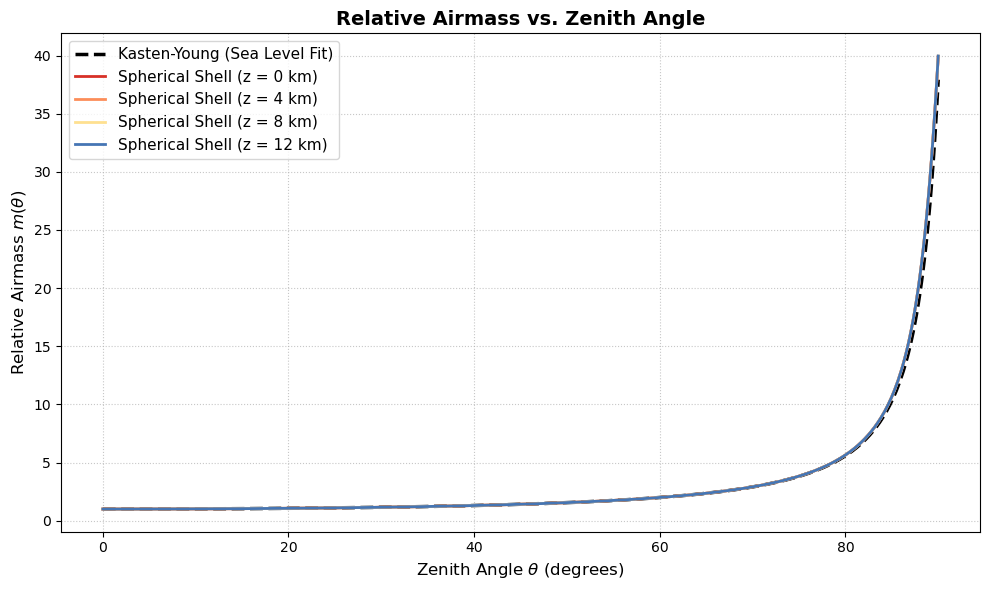

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def airmass_kasten_young(theta_deg):
    """
    Empirical airmass formula by Kasten and Young (1989).
    Valid strictly for sea-level observers.
    Inputs: theta_deg in degrees.
    """
    # Formula exactly as written in the uploaded image
    denominator = np.cos(np.radians(theta_deg)) + 0.50572 * (96.07995 - theta_deg)**(-1.6364)
    return 1.0 / denominator

def airmass_spherical_shell(theta_deg, z, H=8000.0):
    """
    Exact geometric airmass for a spherical atmospheric shell.
    Valid for any altitude and any angle.
    Inputs: theta_deg in degrees, z (altitude) in meters, H (scale height) in meters.
    """
    R_e = 6371e3  # Earth radius in meters
    theta_rad = np.radians(theta_deg)
    
    r = R_e + z
    cos_t = np.cos(theta_rad)
    
    term1 = (r**2) * (cos_t**2)
    term2 = 2 * r * H
    term3 = H**2
    
    return (np.sqrt(term1 + term2 + term3) - r * cos_t) / H


# ==========================================
# Generate Data for Visualization
# ==========================================
# We plot from Zenith (0) to Horizon (90)
theta_grid = np.linspace(0, 90, 500)

# Calculate Kasten-Young (Static, no altitude dependence)
am_ky = airmass_kasten_young(theta_grid)

# Calculate Spherical Shell for various altitudes
altitudes_to_plot = [0, 4000, 8000, 12000] # meters
scale_height = 8000.0 # Using 8km (Dry air) for this comparison

plt.figure(figsize=(10, 6))

# Plot Kasten-Young Baseline
plt.plot(theta_grid, am_ky, 'k--', linewidth=2.5, label='Kasten-Young (Sea Level Fit)')

# Plot Spherical Shell Geometry
colors = ['#d73027', '#fc8d59', '#fee090', '#4575b4']
for z, color in zip(altitudes_to_plot, colors):
    am_sph = airmass_spherical_shell(theta_grid, z, H=scale_height)
    plt.plot(theta_grid, am_sph, color=color, linewidth=2, 
             label=f'Spherical Shell (z = {z/1000:.0f} km)')

# Formatting
plt.title('Relative Airmass vs. Zenith Angle', fontsize=14, fontweight='bold')
plt.xlabel('Zenith Angle $\\theta$ (degrees)', fontsize=12)
plt.ylabel('Relative Airmass $m(\\theta)$', fontsize=12)
#plt.xlim(0, 90)
#plt.ylim(0, 45) # Capped at 45 to clearly see the horizon behavior

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

In [10]:
#let's print the last values at the horizon for z = 0, 4, 8, 12 km
print("Airmass at Horizon (90 degrees):")
for z in altitudes_to_plot:
    am_horizon = airmass_spherical_shell(90, z, H=scale_height)
    print(f"  Altitude {z/1000:.0f} km: Airmass = {am_horizon:.2f}")

Airmass at Horizon (90 degrees):
  Altitude 0 km: Airmass = 39.92
  Altitude 4 km: Airmass = 39.93
  Altitude 8 km: Airmass = 39.95
  Altitude 12 km: Airmass = 39.96


In [11]:
import numpy as np

def compute_T_in(theta_grid, z_part, altitudes, T_phys_profile, T_ground, tau_z_profile):
    """
    Computes the full angular profile of incoming brightness temperature hitting a particle.
    
    Parameters:
    theta_grid     : ND array of zenith angles in radians (e.g., shape (1, N_theta, N_phi))
    z_part         : Scalar, altitude of the active layer/particle in meters
    altitudes      : 1D array of atmospheric profile altitudes in meters (ascending)
    T_phys_profile : 1D array of thermodynamic temperatures corresponding to altitudes
    T_ground       : Scalar, physical temperature of the ground
    tau_z_profile  : 1D array, cumulative optical depth from the ground up to 'altitudes'
    """
    R_e = 6371e3  # Earth radius in meters
    
    # ---------------------------------------------------------
    # 1. EXTRACT LOCAL LAYER PROPERTIES
    # ---------------------------------------------------------
    # Interpolate to find exactly what is happening at z_part
    tau_below = np.interp(z_part, altitudes, tau_z_profile)
    tau_total = tau_z_profile[-1]
    tau_above = tau_total - tau_below
    
    # Estimate effective temperatures of the atmosphere above and below the particle
    mask_above = altitudes >= z_part
    mask_below = altitudes <= z_part
    T_atm_above = np.mean(T_phys_profile[mask_above]) if np.any(mask_above) else T_phys_profile[-1]
    T_atm_below = np.mean(T_phys_profile[mask_below]) if np.any(mask_below) else T_ground

    # ---------------------------------------------------------
    # 2. DEFINE THE ANGULAR BOUNDARIES
    # ---------------------------------------------------------
    theta_h = np.sqrt(2 * z_part / R_e)
    bound_sky = np.pi / 2.0
    bound_limb = (np.pi / 2.0) + theta_h

    # ---------------------------------------------------------
    # 3. ZONE 1: THE UPPER SKY (theta < pi/2)
    # ---------------------------------------------------------
    # Kasten-Young empirical airmass
    theta_deg = np.degrees(theta_grid)
    theta_deg_sky = np.clip(theta_deg, 0, 90.0) 
    m_sky = 1.0 / (np.cos(theta_grid) + 0.50572 * (96.07995 - theta_deg_sky)**(-1.6364))
    
    T_sky = T_atm_above * (1.0 - np.exp(-tau_above * m_sky))

    # ---------------------------------------------------------
    # 4. ZONE 2: THE TANGENT LIMB (pi/2 <= theta <= pi/2 + theta_h)
    # ---------------------------------------------------------
    # Calculate the minimum grazing altitude of the ray
    z_min_grid = (R_e + z_part) * np.sin(theta_grid) - R_e
    
    # Interpolate physical temperature at the grazing altitude
    T_limb_flat = np.interp(z_min_grid.flatten(), altitudes, T_phys_profile)
    T_limb = T_limb_flat.reshape(theta_grid.shape)

    # ---------------------------------------------------------
    # 5. ZONE 3: THE GROUND (theta > pi/2 + theta_h)
    # ---------------------------------------------------------
    # For looking down, we use the downward secant law: 1 / cos(pi - theta)
    # We clip the angle slightly away from exactly 90 deg to prevent division by zero
    theta_down = np.clip(theta_grid, bound_limb + 1e-4, np.pi)
    m_down = 1.0 / np.cos(np.pi - theta_down)
    
    # Emission from the ground (attenuated) + emission from the air below the particle
    T_ground_zone = T_ground * np.exp(-tau_below * m_down) + \
                    T_atm_below * (1.0 - np.exp(-tau_below * m_down))

    # ---------------------------------------------------------
    # 6. STITCH THE ZONES TOGETHER
    # ---------------------------------------------------------
    conditions = [
        theta_grid < bound_sky,
        (theta_grid >= bound_sky) & (theta_grid <= bound_limb),
        theta_grid > bound_limb
    ]
    
    choices = [T_sky, T_limb, T_ground_zone]
    
    T_in = np.select(conditions, choices)
    
    return T_in

In [12]:
alt = np.arange(5000, 10000, 10)
T_phys = 270 - 6.5 * (alt - 5000) / 1000  # Linear decrease with altitude
tau_z = 0.01 * (alt - 5000) / 1000  # Linear increase with altitude
theta_grid = np.radians(np.linspace(0, 180, 500))  # From zenith to nadir
z_part = 7000  # Altitude of the particle
T_ground_in = T_phys[0]  # Ground temperature from the profile
T_in_profile = compute_T_in(theta_grid, z_part, alt, T_phys, T_ground_in, tau_z)

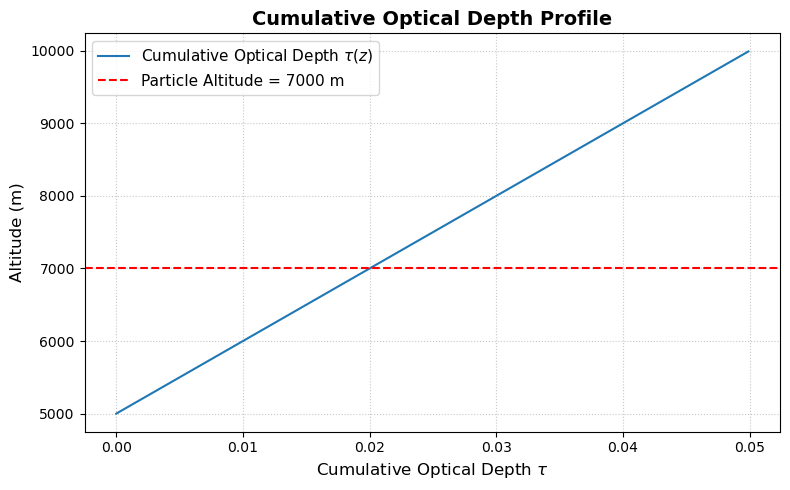

In [13]:
#Let's check tau_z as function of altitude
plt.figure(figsize=(8, 5))
plt.plot(tau_z, alt, label='Cumulative Optical Depth $\\tau(z)$')
plt.axhline(z_part, color='r', linestyle='--', label=f'Particle Altitude = {z_part} m')
plt.xlabel('Cumulative Optical Depth $\\tau$', fontsize=12)
plt.ylabel('Altitude (m)', fontsize=12)
plt.title('Cumulative Optical Depth Profile', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

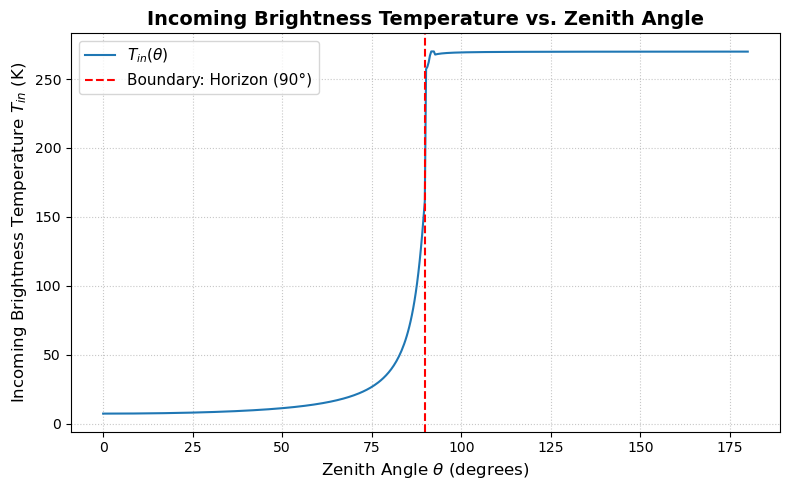

In [14]:
#Let's see T_in as function of theta
plt.figure(figsize=(8, 5))
plt.plot(np.degrees(theta_grid), T_in_profile, label='$T_{in}(\\theta)$')
plt.axvline(90, color='r', linestyle='--', label='Boundary: Horizon (90°)')
plt.xlabel('Zenith Angle $\\theta$ (degrees)', fontsize=12)
plt.ylabel('Incoming Brightness Temperature $T_{in}$ (K)', fontsize=12)
plt.title('Incoming Brightness Temperature vs. Zenith Angle', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()